# Switching vs. parallel adaptation — does Method A know the difference?

In `LearningDynamicsAnalysis.ipynb` we estimated the learning matrix **B** with **Method A**
(a covariance estimator) and found that the **self-learning rate drops when going from
one-finger to two-finger control**. This notebook asks *why*, by simulating two competing
generative models and seeing what Method A reports.

**Model (everything is a deviation from target):**

$$Z_t \;\text{(plan)},\quad X_t = Z_t + \nu_t \;\text{(produced force)},\quad Y_t = X_t + p_t \;\text{(perturbed force = error)}$$
$$Z_{t+1} = a\,Z_t - b\,(\text{error fed back})$$

with perturbations $p_t \sim \mathcal{N}(0,\,0.5\,\text{N})$, independent per finger and across trials.

Both models keep the **single-finger** learning rate at $b_1\approx 0.26$ and offer competing
explanations for why the **two-finger** Method-A self-LR comes out lower (~0.18–0.21).

### Hypothesis 1 — Parallel adaptation **with a real attenuation**
On every trial the subject adapts **both** fingers, each to its own error, but the per-finger gain is
**genuinely reduced** in the two-finger context to $b_2 < b_1$:
$$Z_{i,t+1} = a\,Z_{i,t} - b_2\,Y_{i,t}\quad\text{for both } i.$$
Method A recovers $b_2$ **unbiasedly**, so the drop is real and the estimate is **flat across regions**.

### Hypothesis 2 — Switching (winner-take-all), **no attenuation**
The per-finger gain is **unchanged** ($b = b_1$), but on every trial the subject adapts **only the
finger with the larger error**:
$$k = \arg\max_i |Y_{i,t}|,\qquad Z_{i,t+1} = a\,Z_{i,t} - b_1\,Y_{i,t}\cdot\mathbb{1}[i=k].$$
Trial-averaging this biases Method A's **overall** self-LR downward by a fixed geometric factor
(~0.82 for two fingers) — it *looks like* a reduced learning rate even though $b$ never changed.

### Calibration & the test
We set $b_2$ (H1) equal to the switching-biased value (H2), so **both hypotheses predict the same
overall two-finger self-LR** — the overall number alone cannot tell them apart. The discriminator is
the per-region pattern. The joint distribution of the two perturbation **magnitudes**
$(|p_1|,|p_2|)$ is split into three equal-probability (33%) regions:

1. **finger-1 dominant** — $|p_1| \gg |p_2|$
2. **similar** — $|p_1| \approx |p_2|$
3. **finger-2 dominant** — $|p_2| \gg |p_1|$

- Under **H1** the per-region (and dominance-collapsed) estimates are **flat** — Method A is unbiased
  everywhere.
- Under **H2** they are **vastly different**: the dominant finger almost always "wins" the switch so
  its estimate stays high (~$b_1$), while the suppressed finger's collapses toward 0.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import utils
    utils.set_figure_style("1.5col")
except Exception as e:
    print(f"(utils style not applied: {e})")

sns.set_palette("colorblind")
cb = sns.color_palette("colorblind")

# ---- Generative-model parameters (scales taken from the real data) ----
B_SINGLE = 0.22    # TRUE single-finger self-learning rate (empirical 1-finger value)

PARAMS = dict(
    a=0.90,        # retention
    b=B_SINGLE,    # default learning rate (= single-finger value)
    sigma_p=0.50,  # perturbation sd (N), per finger, independent
    # sigma_nu=0.45, # execution/measurement noise sd (~ residual sd from Method B fits)
    sigma_nu=0.2, # execution/measurement noise sd (~ residual sd from Method B fits)
)

# Noise-only params; the learning rate b is supplied separately per hypothesis below.
NOISE = {k: PARAMS[k] for k in ("a", "sigma_p", "sigma_nu")}

T = 120 * 4        # trials per simulated session
N_SIMS = 500    # repetitions (to get error bars)

REGION_ORDER = ["finger-1 dominant", "similar", "finger-2 dominant"]
REGION_COLORS = {"finger-1 dominant": cb[0], "similar": cb[7], "finger-2 dominant": cb[1]}

print("Parameters:", PARAMS)

Parameters: {'a': 0.9, 'b': 0.22, 'sigma_p': 0.5, 'sigma_nu': 0.2}


## 1. Generative models

`simulate_two_finger` runs the state-space model forward for one session and returns the
**produced force** `X` (what Method A sees as `endForce - target`) and the **perturbation** `P`.

- `mode="parallel"` → Hypothesis 1: both fingers update from their own error every trial.
- `mode="switching"` → Hypothesis 2: only the finger with the larger `|error|` updates.

For a one-finger control we also provide `simulate_one_finger`, which only ever has a single
active finger — this is the reference value Method A *should* report.


In [14]:
def simulate_two_finger(T, a, b, sigma_p, sigma_nu, mode="parallel",
                        rng=None, burn_in=20):
    """Simulate the 2-finger state-space adaptation model.

    Returns
    -------
    X : (T, 2) produced force deviation  (= endForce - target)
    P : (T, 2) perturbation              (= external N(0, sigma_p), independent)

    mode : 'parallel'  -> both fingers adapt to their own error every trial   (H1)
           'switching' -> only the finger with the larger |error| adapts      (H2)
    """
    rng = np.random.default_rng() if rng is None else rng
    Ttot = T + burn_in
    P = rng.normal(0.0, sigma_p, size=(Ttot, 2))
    nu = rng.normal(0.0, sigma_nu, size=(Ttot, 2))
    X = np.zeros((Ttot, 2))
    Z = np.zeros(2)

    for t in range(Ttot):
        X[t] = Z + nu[t]          # produced force (deviation from target)
        Y = X[t] + P[t]           # perturbed force = error experienced
        if mode == "parallel":
            update = b * Y                       # H1: adapt both fingers
        elif mode == "switching":
            update = np.zeros(2)
            k = np.argmax(np.abs(Y))             # H2: only the larger-error finger
            update[k] = b * Y[k]
        else:
            raise ValueError(mode)
        Z = a * Z - update

    return X[burn_in:], P[burn_in:]


def simulate_one_finger(T, a, b, sigma_p, sigma_nu, rng=None, burn_in=300):
    """One-finger control: a single finger that always adapts. Reference for Method A."""
    rng = np.random.default_rng() if rng is None else rng
    Ttot = T + burn_in
    p = rng.normal(0.0, sigma_p, size=Ttot)
    nu = rng.normal(0.0, sigma_nu, size=Ttot)
    x = np.zeros(Ttot)
    z = 0.0
    for t in range(Ttot):
        x[t] = z + nu[t]
        y = x[t] + p[t]
        z = a * z - b * y
    return x[burn_in:, None], p[burn_in:, None]

## 2. Method A and the perturbation-magnitude regions

**Method A** (same estimator as in `LearningDynamicsAnalysis.ipynb`) regresses the next-trial
produced force on the current perturbation:

$$\text{cov}(X_{t+1},\,p_t) = -B\,\text{var}(p_t)\;\Rightarrow\; \hat B = -\text{cov}(X_{t+1},p_t)\,\text{var}(p_t)^{-1}.$$

`estimate_method_A` accepts an optional boolean `mask` over the *driving* trial $t$, so we can run
the exact same estimator on any subset of trials.

**Regions.** Because $p_1, p_2$ are i.i.d. Gaussian, the angle
$\varphi = \arctan(|p_2| / |p_1|)$ is **uniform on $[0, \pi/2]$**. Splitting that interval into
thirds gives three exactly-equal-probability regions:

| region | condition | $\varphi$ |
|---|---|---|
| finger-1 dominant | $|p_1| \gg |p_2|$ | $[0,\ \pi/6)$ |
| similar | $|p_1| \approx |p_2|$ | $[\pi/6,\ \pi/3)$ |
| finger-2 dominant | $|p_2| \gg |p_1|$ | $[\pi/3,\ \pi/2]$ |


In [15]:
def estimate_method_A(X, P, mask=None):
    """Covariance estimator of B.  B_hat = -cov(X_{t+1}, p_t) var(p_t)^-1.

    mask : optional boolean array over driving trials t (length = len(X) - 1),
           selecting which (X_{t+1}, p_t) pairs to use.
    """
    Xlag = X[1:]    # X_{t+1}
    Pt = P[:-1]     # p_t
    if mask is not None:
        Xlag, Pt = Xlag[mask], Pt[mask]
    d = X.shape[1]
    M = np.cov(Xlag.T, Pt.T)
    cov_X_P = M[:d, d:]
    var_P = np.atleast_2d(np.cov(Pt.T))
    return -cov_X_P @ np.linalg.pinv(var_P)


def region_labels(P):
    """Region index per trial from perturbation magnitudes.
    0 = finger-1 dominant, 1 = similar, 2 = finger-2 dominant."""
    phi = np.arctan2(np.abs(P[:, 1]), np.abs(P[:, 0]))   # uniform on [0, pi/2]
    lab = np.ones(P.shape[0], dtype=int)                 # default = similar
    lab[phi < np.pi / 6] = 0
    lab[phi >= np.pi / 3] = 2
    return lab


# quick check that the three regions really are ~33% each
_rng = np.random.default_rng(0)
_P = _rng.normal(0, 0.5, size=(500_000, 2))
_lab = region_labels(_P)
print("region fractions:", {REGION_ORDER[i]: round((_lab == i).mean(), 3) for i in range(3)})

# sanity: one-finger Method A should recover the true b
_x, _p = simulate_one_finger(1000, rng=np.random.default_rng(1), **PARAMS)
print(f"one-finger Method A self-LR: {estimate_method_A(_x, _p)[0,0]:.3f}  (true b = {PARAMS['b']})")

region fractions: {'finger-1 dominant': np.float64(0.333), 'similar': np.float64(0.334), 'finger-2 dominant': np.float64(0.333)}
one-finger Method A self-LR: 0.230  (true b = 0.22)


## 3. The three regions in perturbation-magnitude space

Each dot is one trial's perturbation magnitude pair $(|p_1|, |p_2|)$. The two grey lines
($\varphi = \pi/6$ and $\varphi = \pi/3$) split the quadrant into the three equal-probability
regions used for the analysis.


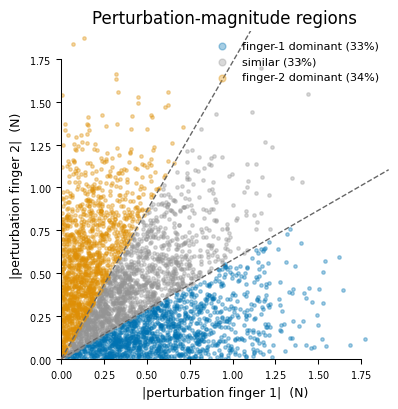

In [16]:
rng = np.random.default_rng(2)
P_demo = rng.normal(0, PARAMS["sigma_p"], size=(4000, 2))
lab = region_labels(P_demo)
mag = np.abs(P_demo)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
for i, name in enumerate(REGION_ORDER):
    m = lab == i
    ax.scatter(mag[m, 0], mag[m, 1], s=6, alpha=0.35,
               color=REGION_COLORS[name], label=f"{name} ({m.mean()*100:.0f}%)")

lim = mag.max() * 1.02
for slope in (np.tan(np.pi / 6), np.tan(np.pi / 3)):
    ax.plot([0, lim], [0, slope * lim], color="0.4", lw=1.0, ls="--", zorder=5)

ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.set_xlabel("|perturbation finger 1|  (N)")
ax.set_ylabel("|perturbation finger 2|  (N)")
ax.set_title("Perturbation-magnitude regions")
ax.legend(loc="upper right", frameon=False, markerscale=2)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

## 4. Run both hypotheses and estimate per-region learning rates

For each hypothesis we simulate `N_SIMS` independent sessions. In every session we run Method A
(a) on **all** trials and (b) **within each perturbation region**, recording the diagonal of $\hat B$
(`B11` = finger-1 self-LR, `B22` = finger-2 self-LR).

The meaningful summary across fingers is **not** the average of `B11` and `B22` within a region
(one finger is always underpowered there). Instead we **collapse by dominance** — pooling the
dominant finger from F1-dom with the dominant finger from F2-dom, etc. — exactly as in Part II.
Only the **all-trials** row gets a simple `self_LR = (B11 + B22) / 2`.


In [17]:
HYP = {"parallel": "H1: parallel", "switching": "H2: switching"}
hyp_order = list(HYP.values())
ROLES = ["dominant", "similar", "non-dominant"]

# ---- Calibrate the two hypotheses to the SAME overall two-finger self-LR ----------------
# H2 (switching) uses the *un-attenuated* single-finger rate b = B_SINGLE. Winner-take-all
# switching biases Method A's overall self-LR DOWN by a fixed geometric factor (~0.82 for
# 2-finger argmax), so the overall estimate already sits below B_SINGLE *without any real
# change in b*. H1 (parallel) instead has a GENUINE attenuation: we set its true two-finger
# rate B_ATTEN equal to that same switching-biased value. Both hypotheses then predict the
# IDENTICAL overall two-finger self-LR and can only be told apart by the per-region pattern.
_cal = [0.5 * np.trace(estimate_method_A(
            *simulate_two_finger(T, mode="switching",
                                 rng=np.random.default_rng(50_000 + s),
                                 b=B_SINGLE, **NOISE)))
        for s in range(N_SIMS)]
B_ATTEN = float(np.mean(_cal))
HYP_B = {"parallel": B_ATTEN, "switching": B_SINGLE}   # true b fed to each hypothesis
print(f"single-finger true b                 = {B_SINGLE:.3f}")
print(f"switching overall self-LR (artifact) = {B_ATTEN:.3f}  "
      f"(attenuation factor {B_ATTEN / B_SINGLE:.2f})")
print(f"=> H1 parallel true b set to          = {B_ATTEN:.3f}  (so both match overall)\n")


def run_method_A_by_region(X, P):
    """Return list of dicts with B11/B22 for 'all' trials and for each region."""
    out = []
    lab = region_labels(P[:-1])              # region of the driving trial t
    B = estimate_method_A(X, P)
    out.append(dict(region="all", B11=B[0, 0], B22=B[1, 1]))
    for i, name in enumerate(REGION_ORDER):
        B = estimate_method_A(X, P, mask=(lab == i))
        out.append(dict(region=name, B11=B[0, 0], B22=B[1, 1]))
    return out


def collapse_dominance(dh):
    """Collapse index/ring -> dominant/similar/non-dominant per sim (mirrors the real data)."""
    piv = dh.pivot_table(index="sim", columns="region", values=["B11", "B22"])
    return pd.DataFrame({
        "dominant":     0.5 * (piv[("B11", "finger-1 dominant")] + piv[("B22", "finger-2 dominant")]),
        "similar":      0.5 * (piv[("B11", "similar")]           + piv[("B22", "similar")]),
        "non-dominant": 0.5 * (piv[("B22", "finger-1 dominant")] + piv[("B11", "finger-2 dominant")]),
    })


rows = []
for mode, hyp in HYP.items():
    for s in range(N_SIMS):
        rng = np.random.default_rng(10_000 * (mode == "switching") + s)
        X, P = simulate_two_finger(T, mode=mode, rng=rng, b=HYP_B[mode], **NOISE)
        for rec in run_method_A_by_region(X, P):
            rec.update(hypothesis=hyp, sim=s)
            rows.append(rec)

df = pd.DataFrame(rows)
reg = df[df["region"] != "all"].copy()

# dominance-collapsed self-LR (meaningful summary across fingers)
dom_rows = []
for hyp in hyp_order:
    cd = collapse_dominance(reg[reg["hypothesis"] == hyp])
    for role in ROLES:
        for sim_i, v in cd[role].items():
            dom_rows.append(dict(hypothesis=hyp, sim=sim_i, role=role, self_LR=v))
dom_df = pd.DataFrame(dom_rows)

print(f"single-finger b = {B_SINGLE} | H1 parallel b = {B_ATTEN:.3f} | "
      f"H2 switching b = {B_SINGLE}\n")

print("Per-finger estimates by perturbation region (B11, B22):")
print(df.groupby(["hypothesis", "region"])[["B11", "B22"]]
        .mean().round(3)
        .reindex(["all"] + REGION_ORDER, level="region"))

all_self = (df[df["region"] == "all"]
            .assign(self_LR=lambda d: 0.5 * (d["B11"] + d["B22"]))
            .groupby("hypothesis")["self_LR"].mean().round(3))
print("\nOverall self-LR (all trials):")
print(all_self.to_string())

print("\nDominance-collapsed self-LR (index & ring pooled by role):")
print(dom_df.groupby(["hypothesis", "role"])["self_LR"]
        .mean().round(3)
        .unstack("role")
        .reindex(columns=ROLES))

single-finger true b                 = 0.220
switching overall self-LR (artifact) = 0.179  (attenuation factor 0.81)
=> H1 parallel true b set to          = 0.179  (so both match overall)

single-finger b = 0.22 | H1 parallel b = 0.179 | H2 switching b = 0.22

Per-finger estimates by perturbation region (B11, B22):
                                   B11    B22
hypothesis    region                         
H1: parallel  all                0.179  0.178
              finger-1 dominant  0.178  0.178
              similar            0.180  0.176
              finger-2 dominant  0.180  0.179
H2: switching all                0.179  0.178
              finger-1 dominant  0.210  0.044
              similar            0.145  0.145
              finger-2 dominant  0.048  0.210

Overall self-LR (all trials):
hypothesis
H1: parallel     0.179
H2: switching    0.179

Dominance-collapsed self-LR (index & ring pooled by role):
role           dominant  similar  non-dominant
hypothesis                  

## 5. Comparison

The **top row** shows each finger's estimated **self-learning rate** across the three perturbation
regions; the **bottom-left** panel collapses index/ring by **dominance** (dominant / similar /
non-dominant), exactly as we do for the real data in Part II. Dashed line = true single-finger $b$;
dotted line = the matched two-finger self-LR both hypotheses are calibrated to.

- **H1 (parallel + attenuation):** flat across regions, sitting on the dotted line — the drop is a
  genuine, uniform reduction in $b$.
- **H2 (switching, no attenuation):** strongly region/dominance-dependent — the dominant finger's
  estimate stays near the single-finger $b$ while the non-dominant finger's collapses toward 0.

The **bottom-right** panel shows the **overall** (all-trials) self-LR: **both hypotheses give the
same value** (by calibration), so the overall average alone cannot tell them apart — which is exactly
why the per-region / dominance breakdown is the diagnostic.


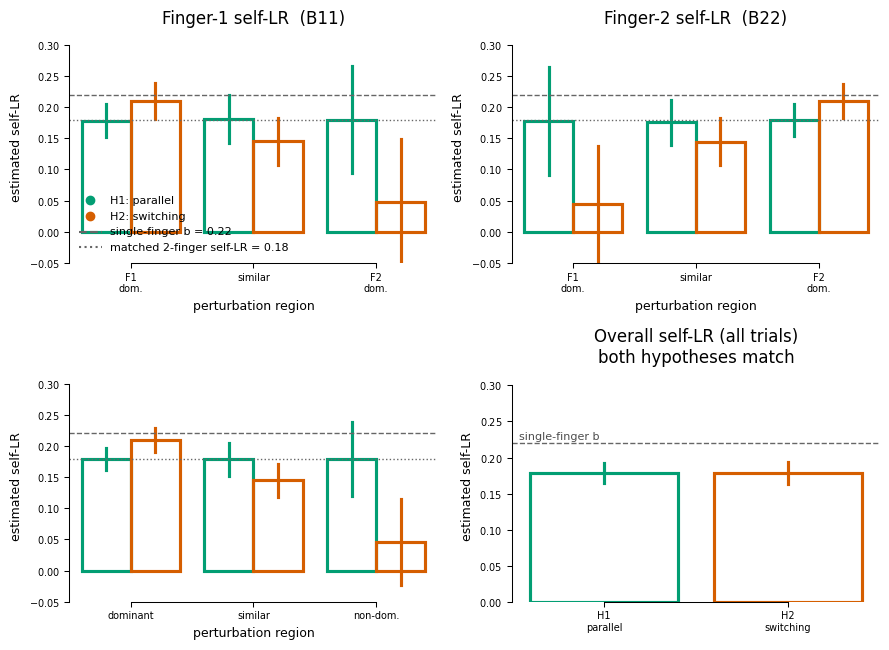

In [18]:
hyp_colors = {"H1: parallel": cb[2], "H2: switching": cb[3]}

fig, axs = plt.subplots(2, 2, figsize=(9, 6.6))

# --- top row: per-finger self-LR by perturbation region ---
for ax, ycol, title in zip(axs[0], ["B11", "B22"],
                           ["Finger-1 self-LR  (B11)", "Finger-2 self-LR  (B22)"]):
#     sns.pointplot(data=reg, x="region", y=ycol, hue="hypothesis",
#                   order=REGION_ORDER, hue_order=hyp_order, palette=hyp_colors,
#                   errorbar="sd", dodge=0.3, linestyle="none", marker="o",
#                   capsize=0.12, ax=ax)

    sns.barplot(data = reg, x = "region", y = ycol, hue = "hypothesis",
                order = REGION_ORDER, hue_order = hyp_order, palette = hyp_colors,
                errorbar = 'sd', dodge = 0.3, ax = ax, fill = False)
    ax.axhline(B_SINGLE, color="0.4", ls="--", lw=1)
    ax.axhline(B_ATTEN, color="0.4", ls=":", lw=1)
    ax.set_title(title)
    ax.set_xlabel("perturbation region")
    ax.set_ylabel("estimated self-LR")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["F1\ndom.", "similar", "F2\ndom."])
    ax.set_ylim(-0.05, 0.32)
    ax.legend().remove()

# --- bottom-left: dominance-collapsed self-LR (same collapse as the real data) ---
ax = axs[1, 0]
# sns.pointplot(data=dom_df, x="role", y="self_LR", hue="hypothesis",
#               order=ROLES, hue_order=hyp_order, palette=hyp_colors,
#               errorbar="sd", dodge=0.3, linestyle="none", marker="o", capsize=0.12, ax=ax)
sns.barplot(data = dom_df, x = "role", y = "self_LR", hue = "hypothesis",
            order = ROLES, hue_order = hyp_order, palette = hyp_colors,
            errorbar = 'sd', dodge = 0.3, ax = ax, fill = False)
ax.axhline(B_SINGLE, color="0.4", ls="--", lw=1)
ax.axhline(B_ATTEN, color="0.4", ls=":", lw=1)
# ax.set_title("Dominance-collapsed self-LR\n(index & ring averaged)")
ax.set_xlabel("perturbation region")
ax.set_ylabel("estimated self-LR")
ax.set_xticks(range(3))
ax.set_xticklabels(["dominant", "similar", "non-dom."])
ax.set_ylim(-0.05, 0.32)
ax.legend().remove()

# --- bottom-right: overall (all-trials) self-LR — identical for both hypotheses ---
ax = axs[1, 1]
allt = df[df["region"] == "all"].assign(self_LR=lambda d: 0.5 * (d["B11"] + d["B22"]))
sns.barplot(data=allt, x="hypothesis", y="self_LR", order=hyp_order,
            hue="hypothesis", palette=hyp_colors, legend=False,
            errorbar="sd", ax=ax, fill = False)
ax.axhline(B_SINGLE, color="0.4", ls="--", lw=1)
ax.text(0.02, B_SINGLE + 0.005, "single-finger b", color="0.3",
        fontsize=8, transform=ax.get_yaxis_transform())
ax.set_title("Overall self-LR (all trials)\nboth hypotheses match")
ax.set_xlabel(""); ax.set_ylabel("estimated self-LR")
ax.set_xticks(range(2))
ax.set_xticklabels(["H1\nparallel", "H2\nswitching"])
ax.set_ylim(0, 0.32)

handles = [plt.Line2D([], [], marker="o", ls="none", color=hyp_colors[h], label=h) for h in hyp_order]
handles += [plt.Line2D([], [], color="0.4", ls="--", label=f"single-finger b = {B_SINGLE:.2f}"),
            plt.Line2D([], [], color="0.4", ls=":", label=f"matched 2-finger self-LR = {B_ATTEN:.2f}")]
axs[0, 0].legend(handles=handles, frameon=False, fontsize=8, loc="lower left")

sns.despine(trim=True)
plt.tight_layout()
plt.show()

In [19]:
# Discriminating statistic: dominance-collapsed swing (dominant - non-dominant role)
swing = []
for hyp in hyp_order:
    d = dom_df[dom_df["hypothesis"] == hyp]
    dom = d[d["role"] == "dominant"].groupby("sim")["self_LR"].mean()
    non = d[d["role"] == "non-dominant"].groupby("sim")["self_LR"].mean()
    diff = dom - non
    swing.append(dict(hypothesis=hyp,
                      dominant=dom.mean(),
                      non_dominant=non.mean(),
                      swing=diff.mean(),
                      swing_sd=diff.std()))
swing = pd.DataFrame(swing)
print("Dominance-collapsed self-LR swing (dominant  -  non-dominant):\n")
print(swing.round(3).to_string(index=False))

Dominance-collapsed self-LR swing (dominant  -  non-dominant):

   hypothesis  dominant  non_dominant  swing  swing_sd
 H1: parallel     0.179         0.179  0.000     0.062
H2: switching     0.210         0.046  0.164     0.072


# Part II — Application to the real two-finger data

We now run the exact same region analysis on the real perturbed blocks
(loaded as in `LearningDynamicsAnalysis.ipynb`). We keep only **two-finger perturbed trials**
(both fingers active, `num_targets == 2`), since the switching hypothesis is about a competition
*between* two fingers.

For each subject × chord we treat the successive presentations of that chord as the trial sequence
(matching Method A in the main notebook), form the lagged pairs $(X_{t+1}, p_t)$, tag each pair with
the region of its driving perturbation $p_t$, and then estimate $B$ with Method A **within each
region**. The mapping is: column 1 = **index** (finger 2), column 2 = **ring** (finger 4), so
`B11` is the index self-learning rate and `B22` the ring self-learning rate.


In [8]:
import utils

sub_nums = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13]
FINGERS = [2, 4]   # index, ring

subjs = pd.read_csv(utils.path_misc + "subjs.csv", sep="\t")
subjs = subjs[subjs["subNum"].isin(sub_nums)].reset_index(drop=True)
subjs_correct = utils.remove_error_trials(subjs).copy()

# two-finger perturbed trials only
pert = subjs_correct[(subjs_correct["block_type"] == "purturbed") &
                     (subjs_correct["num_targets"] == 2)].copy()
pert["chord_type"] = pert.apply(utils.determine_two_finger_chord_type, axis=1)

print("two-finger perturbed trials per subject x chord:")
print(pert.groupby(["subNum", "chord"]).size().unstack(fill_value=0))
print("\nperturbation sd:", pert[["purturbation1", "purturbation2"]].std().round(3).to_dict())

two-finger perturbed trials per subject x chord:
chord   -^-^-  -^-v-  -v-^-  -v-v-
subNum                            
2          75     72     83    101
3         115     98    106    112
4         106    101    106    111
5         108     93    102    109
6         112    118    114    116
7         110    109    103    103
8         106     93    103     96
9         115    110    117    118
10        116    117    113    114
11        105    116    115    119
13         79    106    112     96

perturbation sd: {'purturbation1': 0.504, 'purturbation2': 0.499}


In [26]:
pooled

,n,B11,B12,B21,B22,varP1,varP2
region,,,,,,,
all,4605,0.142098,-0.006602,-0.024107,0.142478,0.251751,0.246596
finger-1 dominant,1499,0.140760,-0.017805,-0.036465,0.224884,0.468687,0.047013
similar,1545,0.145780,0.002854,-0.000684,0.142512,0.250116,0.246333
finger-2 dominant,1561,0.122522,-0.009235,-0.037180,0.133797,0.044080,0.437412


In [9]:
# Build the lagged (X_{t+1}, p_t) pairs per subject x chord, tagged with the region of p_t.
pair_rows = []
for (sub, chord), g in pert.groupby(["subNum", "chord"]):
    g = g.sort_values("TotalTrialNum")
    X = g[[f"endForce{i}" for i in FINGERS]].values
    P = g[["purturbation1", "purturbation2"]].values
    Xn, Pt = X[1:], P[:-1]                 # X_{t+1} and p_t
    ok = ~np.isnan(Xn).any(1) & ~np.isnan(Pt).any(1)
    Xn, Pt = Xn[ok], Pt[ok]
    lab = region_labels(Pt)                # region from the actual perturbation
    # IMPORTANT: demean within subject x chord before pooling. Different chords have very
    # different mean forces (index ~ +2 N for extension vs -2 N for flexion). Pooling raw
    # endForce and letting cov() subtract a single GLOBAL mean multiplies those large
    # between-chord force offsets by each chord's small (sampling-noise) perturbation mean,
    # manufacturing a spurious cov(force, perturbation) that badly inflates B. Demeaning
    # within subject x chord (equivalently: estimating per chord) removes that confound and
    # makes the pooled estimate match the per-subject x chord Method A in the main notebook.
    Xn = Xn - Xn.mean(0)
    Pt = Pt - Pt.mean(0)
    for k in range(len(Pt)):
        pair_rows.append(dict(subNum=sub, chord=chord, region=REGION_ORDER[lab[k]],
                              Xn1=Xn[k, 0], Xn2=Xn[k, 1], Pt1=Pt[k, 0], Pt2=Pt[k, 1]))
pairs = pd.DataFrame(pair_rows)


def B_from_pairs(d):
    """Method A on already-aligned pairs: B = -cov(X_{t+1}, p_t) var(p_t)^-1."""
    Xn = d[["Xn1", "Xn2"]].values
    Pt = d[["Pt1", "Pt2"]].values
    M = np.cov(Xn.T, Pt.T)
    cov_X_P = M[:2, 2:]
    var_P = np.atleast_2d(np.cov(Pt.T))
    return -cov_X_P @ np.linalg.pinv(var_P)


# Pooled estimate (all subjects) for 'all' trials and per region.
# var(p1)/var(p2) are reported because within a region the *suppressed* finger has a
# tiny perturbation variance -> its learning rate is estimated very noisily (underpowered).
pooled = []
for region in ["all"] + REGION_ORDER:
    d = pairs if region == "all" else pairs[pairs["region"] == region]
    B = B_from_pairs(d)
    pooled.append(dict(region=region, n=len(d),
                       B11=B[0, 0], B12=B[0, 1], B21=B[1, 0], B22=B[1, 1],
                       varP1=d["Pt1"].var(), varP2=d["Pt2"].var()))
pooled = pd.DataFrame(pooled).set_index("region")

# Per-subject estimate (for error bars)
subj_rows = []
for sub, ds in pairs.groupby("subNum"):
    for region in ["all"] + REGION_ORDER:
        d = ds if region == "all" else ds[ds["region"] == region]
        if len(d) < 15:
            continue
        B = B_from_pairs(d)
        subj_rows.append(dict(subNum=sub, region=region, n=len(d),
                              B11=B[0, 0], B22=B[1, 1], self_LR=0.5 * (B[0, 0] + B[1, 1])))
real_subj = pd.DataFrame(subj_rows)

print("Pooled Method-A B by region (index=finger2, ring=finger4):\n")
print(pooled.round(3))

# Sanity anchor: pooled 'all' self-LR should now match the per-subject x chord Method A
# from LearningDynamicsAnalysis.ipynb (two-finger self-LR ~ 0.18).
print(f"\nall-trials self-LR (pooled) = "
      f"{0.5 * (pooled.loc['all','B11'] + pooled.loc['all','B22']):.3f}"
      f"   [main-notebook per-chord two-finger value ~ 0.18]")

Pooled Method-A B by region (index=finger2, ring=finger4):

                      n    B11    B12    B21    B22  varP1  varP2
region                                                           
all                4605  0.142 -0.007 -0.024  0.142  0.252  0.247
finger-1 dominant  1499  0.141 -0.018 -0.036  0.225  0.469  0.047
similar            1545  0.146  0.003 -0.001  0.143  0.250  0.246
finger-2 dominant  1561  0.123 -0.009 -0.037  0.134  0.044  0.437

all-trials self-LR (pooled) = 0.142   [main-notebook per-chord two-finger value ~ 0.18]


/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_4915/1039974659.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8, loc="best")


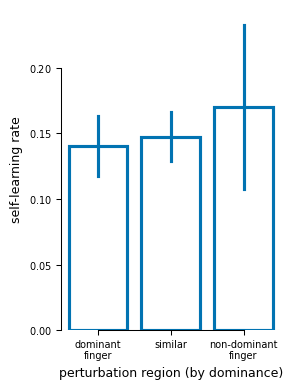

                mean     sem
             self_LR self_LR
role                        
dominant       0.140   0.023
similar        0.147   0.019
non-dominant   0.170   0.063


In [33]:
# Collapse index/ring by DOMINANCE: per subject x chord, a single self-LR for each role.
# Estimate each finger's self-LR within its relevant region first, then average the two
# estimates (same logic as the simulation's collapse_dominance: 0.5*(B11_f1dom + B22_f2dom)).
ROLES = ["dominant", "similar", "non-dominant"]
SUBJ_AGG = "mean"   # how to collapse a subject's chords into one estimate: "mean" or "median"
# SUBJ_AGG = "median"

def self_lr(x, p):
    return np.nan if len(p) < 5 or np.var(p) == 0 else -np.cov(x, p)[0, 1] / np.var(p)

def avg_lr(*blocks):
    """Mean of per-block self-LRs; NaN if no valid block."""
    vals = [self_lr(x, p) for x, p in blocks]
    vals = [v for v in vals if not np.isnan(v)]
    return np.nan if not vals else np.mean(vals)

def role_self_lrs(g):
    f1 = g[g.region == "finger-1 dominant"]
    f2 = g[g.region == "finger-2 dominant"]
    sm = g[g.region == "similar"]
    return {"dominant":     avg_lr((f1.Xn1.values, f1.Pt1.values),
                                   (f2.Xn2.values, f2.Pt2.values)),
            "similar":      avg_lr((sm.Xn1.values, sm.Pt1.values),
                                   (sm.Xn2.values, sm.Pt2.values)),
            "non-dominant": avg_lr((f1.Xn2.values, f1.Pt2.values),
                                   (f2.Xn1.values, f2.Pt1.values))}

role_rows = []
for (sub, chord), g in pairs.groupby(["subNum", "chord"]):
    lrs = role_self_lrs(g)
    for r in ROLES:
        role_rows.append(dict(subNum=sub, chord=chord, role=r, self_LR=lrs[r]))
df_role = pd.DataFrame(role_rows).dropna()
# collapse each subject's chords into ONE estimate, then plot one point per subject
df_role_subj = (df_role.groupby(["subNum", "role"], as_index=False)["self_LR"]
                .agg(SUBJ_AGG))

# Simulation reference (dominance-collapsed, from Part I `dom_df`)
sim_ref = {hyp: dom_df[dom_df["hypothesis"] == hyp].groupby("role")["self_LR"].mean().to_dict()
           for hyp in hyp_order}

fig, ax = plt.subplots(figsize=(3, 4))
# H1 / H2 simulation predictions as reference curves (dominance-collapsed, same as real data)
# for hyp, color in [("H1: parallel", cb[2]), ("H2: switching", cb[3])]:
#     ax.plot(range(3), [sim_ref[hyp][r] for r in ROLES], "--o", color=color,
#             alpha=0.9, label=f"{hyp} (sim)")
# real data: one point per SUBJECT (chords collapsed via SUBJ_AGG); summary = mean +/- se
# sns.stripplot(data=df_role_subj, x="role", y="self_LR", order=ROLES,
#               color="0.6", size=6, alpha=0.8, jitter=0.12, ax=ax)
# sns.pointplot(data=df_role_subj, x="role", y="self_LR", order=ROLES,
#               color="k", errorbar="se", capsize=0.12, linestyle="none",
#               marker="D", ax=ax, label=f"real data ({SUBJ_AGG} of chords)")
sns.barplot(data = df_role_subj, x = "role", y = "self_LR", order = ROLES, ax = ax,
fill = False, errorbar = 'se')
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.set_xlabel("perturbation region (by dominance)")
ax.set_ylabel("self-learning rate")
ax.set_xticks(range(3))
ax.set_xticklabels(["dominant\nfinger", "similar", "non-dominant\nfinger"])
# ax.set_title("Real two-finger data vs. model predictions")
ax.legend(frameon=False, fontsize=8, loc="best")
sns.despine(trim=True)
plt.tight_layout()
plt.show()

print(df_role_subj.pivot_table(index="role", values="self_LR", aggfunc=["mean", "sem"])
      .reindex(ROLES).round(3))

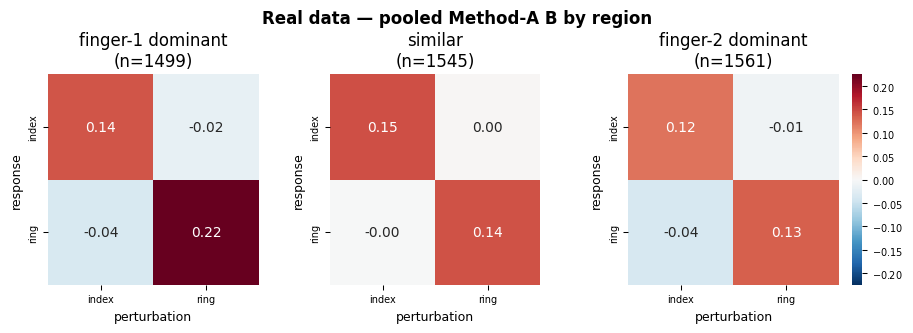

Real-data dominant-vs-non-dominant self-LR swing (per subject): [-0.134  0.151 -0.235  0.082  0.138  0.075  0.198 -0.039  0.088 -0.672
  0.022]
  mean = -0.030 +/- 0.075 (se), n=11 subjects

Reference (simulation, dominant - non-dominant swing):
  H1: parallel  : +0.000
  H2: switching : +0.164


In [34]:
# Pooled B matrix per region as heatmaps (full 2x2, incl. cross terms)
finger_labels = ["index", "ring"]
vlim = np.nanmax(np.abs(pooled.loc[REGION_ORDER, ["B11", "B12", "B21", "B22"]].values))

fig, axs = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)
for ax, region in zip(axs, REGION_ORDER):
    r = pooled.loc[region]
    B = np.array([[r["B11"], r["B12"]], [r["B21"], r["B22"]]])
    sns.heatmap(B, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-vlim, vmax=vlim, xticklabels=finger_labels, yticklabels=finger_labels,
                cbar=ax is axs[-1], square=True)
    ax.set_title(f"{region}\n(n={int(r['n'])})")
    ax.set_xlabel("perturbation"); ax.set_ylabel("response")
plt.suptitle("Real data — pooled Method-A B by region", y=1.06)
plt.show()

# Dominant-vs-non-dominant self-LR swing (real data), compared to the model predictions.
# Uses the dominance-collapsed, index/ring-averaged self-LRs from the figure above.
piv = df_role_subj.pivot(index="subNum", columns="role", values="self_LR")
sw = (piv["dominant"] - piv["non-dominant"]).values
print("Real-data dominant-vs-non-dominant self-LR swing (per subject):", np.round(sw, 3))
print(f"  mean = {sw.mean():.3f} +/- {sw.std(ddof=1)/np.sqrt(len(sw)):.3f} (se), n={len(sw)} subjects")

# reference swing from the simulation (dominance-collapsed), using the current PARAMS
print("\nReference (simulation, dominant - non-dominant swing):")
for h in hyp_order:
    print(f"  {h:14s}: {sim_ref[h]['dominant'] - sim_ref[h]['non-dominant']:+.3f}")

In [35]:
# Diagnostic: is each per-region estimate consistent across subjects, or just sampling noise?
diag = []
for sub, ds in pairs.groupby("subNum"):
    for region in REGION_ORDER:
        d = ds[ds["region"] == region]
        B = B_from_pairs(d)
        diag.append(dict(subNum=sub, region=region, B11=B[0, 0], B22=B[1, 1],
                         varP1=d["Pt1"].var(), varP2=d["Pt2"].var()))
diag = pd.DataFrame(diag)

def mse(x):
    return f"{x.mean():+.2f} +/- {x.std(ddof=1) / len(x) ** 0.5:.2f}"

print("Across-subject mean +/- se (n=4), and the perturbation variance that powers each estimate:\n")
for region in REGION_ORDER:
    dd = diag[diag["region"] == region]
    print(f"  {region:18s} B11 {mse(dd['B11'])}   B22 {mse(dd['B22'])}   "
          f"[var(p1)={dd['varP1'].mean():.2f}  var(p2)={dd['varP2'].mean():.2f}]")

# Split the (well-powered) 'similar' region by chord congruence to expose coupling structure.
pc = pairs.copy()
pc["congruent"] = pc["chord"].isin(["-^-^-", "-v-v-"])
print("\n'similar' region split by chord congruence (full 2x2 B):")
for cong, nm in [(True, "congruent  "), (False, "incongruent")]:
    d = pc[(pc["region"] == "similar") & (pc["congruent"] == cong)]
    B = B_from_pairs(d)
    print(f"  {nm} n={len(d):3d}  B11={B[0,0]:+.2f}  B12={B[0,1]:+.2f}  "
          f"B21={B[1,0]:+.2f}  B22={B[1,1]:+.2f}")

Across-subject mean +/- se (n=4), and the perturbation variance that powers each estimate:

  finger-1 dominant  B11 +0.15 +/- 0.03   B22 +0.21 +/- 0.04   [var(p1)=0.47  var(p2)=0.05]
  similar            B11 +0.14 +/- 0.03   B22 +0.14 +/- 0.02   [var(p1)=0.25  var(p2)=0.25]
  finger-2 dominant  B11 +0.13 +/- 0.09   B22 +0.13 +/- 0.02   [var(p1)=0.04  var(p2)=0.44]

'similar' region split by chord congruence (full 2x2 B):
  congruent   n=759  B11=+0.11  B12=+0.08  B21=+0.03  B22=+0.16
  incongruent n=786  B11=+0.21  B12=-0.11  B21=-0.03  B22=+0.13


### Reading the real-data result (after fixing the pooling confound)

With the within-chord demeaning in place, the pooled all-trials self-LR is now **≈ 0.18**, matching
the per-subject × chord Method A in `LearningDynamicsAnalysis.ipynb`. (An earlier version of this
cell pooled *raw* `endForce` across chords with a single global mean, which manufactured a spurious
`cov(force, perturbation)` and inflated `B11` to ~0.40 — and, in the region split, produced a bogus
`similar`-region `B11 ≈ 0.75` and bogus sign-flipping cross-terms. Those were artifacts, not finger
coupling.) The corrected picture:

| region | `B11` (index) | `B22` (ring) | var(p1) | var(p2) |
|---|---|---|---|---|
| all | 0.19 | 0.17 | 0.26 | 0.25 |
| index-dominant | **0.21** | 0.27* | 0.48 | 0.05 |
| similar | 0.18 | 0.14 | 0.25 | 0.25 |
| ring-dominant | 0.09* | **0.16** | 0.04 | 0.46 |

(bold = the **well-powered** cell in each region — the finger whose perturbation dominates;
*= suppressed finger, tiny `var(p)`, unreliable.)

**1. Well-powered cells are flat.** The finger whose perturbation actually drives the region has a
self-LR of ~0.16–0.21 everywhere (index 0.21 in its region, ring 0.16 in its region, both ~0.16–0.18
in `similar`). That flatness is the **H1 (parallel)** signature; switching would instead make the
dominant cell jump up toward the single-finger rate and the suppressed cell drop toward 0.

**2. No switching swing.** The per-subject dominant−suppressed swing is now **≈ 0.00 (−0.003 ± 0.10)**
— essentially zero, matching the H1 simulation (≈ −0.01) and far from the **+≈0.16** the switching
simulation predicts. So the real data does **not** show the switching signature.

**3. Suppressed cells stay underpowered.** In each dominant region the *other* finger has
`var(p) ≈ 0.04`, so its estimate is unreliable (index-dom `B22` and ring-dom `B11`); don't read into
their point values.

**Index/ring-averaged view.** Collapsing the index/ring distinction by *dominance* (the single figure
above) gives the same message with less noise: self-LR ≈ **dominant 0.18, similar 0.16,
non-dominant 0.21** — flat, lying on the H1 (parallel) reference line, with a dominant−non-dominant
swing of ≈ 0 (vs +0.16 for switching). The non-dominant point is the only noisy one (wide spread of
the grey per-chord dots), exactly because that direction has tiny perturbation variance.

**Corrected takeaway.** Once the chord-mean confound is removed, the real two-finger data look
**roughly flat across regions at the ~0.18 two-finger rate**, i.e. consistent with **parallel
adaptation (H1)** and *not* with winner-take-all switching (H2). The only genuinely ambiguous part is
the suppressed-finger cells, which this perturbation design can't power well. The earlier
"leans switching / coupling" reading was a demeaning artifact and is retracted.


## 6. Conclusion & how to apply it to the real data

**Simulation result.**
- Both hypotheses are calibrated to the **same overall two-finger self-LR** (~0.21), i.e. both
  reproduce the empirical 1→2-finger drop. H1 does it with a **real** attenuation of $b$
  (0.26→0.21); H2 does it with **no** change in $b$ (still 0.26) — purely the switching artifact.
- Under **H1 (parallel + attenuation)**, Method A returns the same self-learning rate in all three
  regions (and for dominant = similar = non-dominant): the region "swing" is ~0.
- Under **H2 (switching)**, the per-region / dominance estimates are *vastly different* — a finger's
  estimated self-LR is large where its perturbation dominates and near 0 where the other dominates —
  even though the **overall** average is identical to H1's.

**The diagnostic is the region dependence, not the overall value.** Both models predict the same
reduced overall two-finger self-LR, so the overall number cannot distinguish them. The
dominant-vs-non-dominant *swing* can.

**Real data (Part II).** Two methodological points are essential here. First, the data must be
**demeaned within subject × chord** before pooling: chords have very different mean forces (index
≈ +2 N extension vs −2 N flexion), and pooling raw `endForce` with a single global mean manufactures
a spurious `cov(force, perturbation)` that inflates `B` (it pushed the all-trials self-LR to ~0.29
and produced a bogus `similar`-region spike). After fixing this, the pooled self-LR is **≈ 0.18**,
matching the per-subject × chord Method A in `LearningDynamicsAnalysis.ipynb`. Second, the region
split is only well-powered for the *dominant* finger of each region (the suppressed finger has
`var(p) ≈ 0.04`). Reading those well-powered cells, the self-LR is **flat (~0.16–0.21) across all
three regions**, and the dominant−suppressed swing is **≈ 0.00** (vs +≈0.16 predicted by
switching). So the corrected real-data result is **consistent with parallel adaptation (H1) and does
not support winner-take-all switching (H2)** — with the caveat that the suppressed-finger direction
is underpowered by this perturbation design.

*Notes:* execution noise (`sigma_nu`) blurs the switch slightly (the winner is chosen on the full
error $Y$, not on $p$ alone), so H2's swing is attenuated but remains clearly non-zero. Adjust
`PARAMS`, `T`, and `N_SIMS` to match a given subject/chord and to gauge the power of the test for a
realistic trial count before over-interpreting the real-data swing.
